# 🏥 Data Warehouse – Farmacia MediData
## Extracción del Conocimiento de Base de Datos | UTCV | 2026
# Daniel Eduardo Pizarro Macuixtle
# Fecha: 10/06/2026


### Arquitectura utilizada
- **Esquema:** Estrella (Star Schema)
- **Tabla de hechos:** `fact_ventas`
- **Dimensiones:** `dim_tiempo`, `dim_producto`, `dim_cliente`, `dim_sucursal`

In [45]:
## 1. Instalación de Dependencias
# Instalar librerías necesarias

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sqlalchemy import create_engine, text
from faker import Faker
import random
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Configuración de estilo para gráficas
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid', palette='muted')

fake = Faker('es_MX')  # Datos en español / México
random.seed(42)
np.random.seed(42)


## Conexión a PostgreSQL


In [46]:
# ─── CREDENCIALES DE CONEXIÓN ──────────────────────────────────
DB_USER     = 'postgres'
DB_PASSWORD = 'Angela2001.'   
DB_HOST     = 'localhost'
DB_PORT     = '5432'
DB_NAME     = 'dw_farmacias'
# ───────────────────────────────────────────────────────────────

CONNECTION_STRING = f'postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}'

try:
    engine = create_engine(CONNECTION_STRING)
    with engine.connect() as conn:
        result = conn.execute(text('SELECT version()'))
        version = result.fetchone()[0]
    print(f'Conexión exitosa a PostgreSQL')
    print(f'{version[:60]}...')
except Exception as e:
    print(f' Error de conexión: {e}')
    print('   Verifica que PostgreSQL esté activo y las credenciales sean correctas.')

Conexión exitosa a PostgreSQL
PostgreSQL 18.1 on x86_64-windows, compiled by msvc-19.44.35...


## Generación de Datos Sintéticos (Extracción / Simulación)


In [47]:
# ─── DATOS MAESTROS ────────────────────────────────────────────────────────

PRODUCTOS = [
    ('Paracetamol 500mg', 'Analgésico', 'Laboratorios Pisa', 25.50, False),
    ('Ibuprofeno 400mg', 'Analgésico', 'Liomont', 38.00, False),
    ('Amoxicilina 500mg', 'Antibiótico', 'Rimsa', 95.00, True),
    ('Omeprazol 20mg', 'Gastrointestinal', 'Laboratorios Sophia', 62.00, True),
    ('Loratadina 10mg', 'Antialérgico', 'Armstrong', 45.00, False),
    ('Metformina 850mg', 'Antidiabético', 'Novartis Mexico', 120.00, True),
    ('Enalapril 10mg', 'Cardiovascular', 'Pfizer Mexico', 85.00, True),
    ('Vitamina C 1g', 'Suplemento', 'Bayer Mexico', 55.00, False),
    ('Dexametasona 8mg', 'Antiinflamatorio', 'Laboratorios Pisa', 78.00, True),
    ('Salbutamol Inhaler', 'Respiratorio', 'GlaxoSmithKline', 210.00, True),
    ('Ciprofloxacino 500mg', 'Antibiótico', 'Rimsa', 110.00, True),
    ('Complejo B', 'Suplemento', 'Armstrong', 42.00, False),
    ('Naproxeno 250mg', 'Analgésico', 'Liomont', 35.00, False),
    ('Ranitidina 150mg', 'Gastrointestinal', 'Laboratorios Sophia', 55.00, False),
    ('Insulina Glargina', 'Antidiabético', 'Sanofi Mexico', 650.00, True),
]

SUCURSALES = [
    ('Sucursal Orizaba Centro', 'Orizaba', 'Región Centro'),
    ('Sucursal Veracruz Puerto', 'Veracruz', 'Región Costa'),
    ('Sucursal Xalapa Norte', 'Xalapa', 'Región Capital'),
    ('Sucursal Córdoba Sur', 'Córdoba', 'Región Centro'),
]

MUNICIPIOS_VER = [
    'Orizaba', 'Veracruz', 'Xalapa', 'Córdoba', 'Coatzacoalcos',
    'Poza Rica', 'Tuxpan', 'Martínez de la Torre', 'Minatitlán', 'Boca del Río'
]

MESES_ES = {
    1:'Enero', 2:'Febrero', 3:'Marzo', 4:'Abril', 5:'Mayo', 6:'Junio',
    7:'Julio', 8:'Agosto', 9:'Septiembre', 10:'Octubre', 11:'Noviembre', 12:'Diciembre'
}

print(f'Catálogos definidos: {len(PRODUCTOS)} productos, {len(SUCURSALES)} sucursales')

Catálogos definidos: 15 productos, 4 sucursales


In [48]:
# ─── GENERACIÓN DE DIMENSIONES ─────────────────────────────────────────────

# dim_tiempo: rango 2022-2025
fechas = pd.date_range('2022-01-01', '2025-12-31', freq='D')
df_tiempo = pd.DataFrame({
    'fecha': fechas,
    'dia': fechas.day,
    'mes': fechas.month,
    'trimestre': fechas.quarter,
    'anio': fechas.year,
    'nombre_mes': [MESES_ES[m] for m in fechas.month],
    'es_fin_semana': fechas.dayofweek >= 5
})
print(f'dim_tiempo: {len(df_tiempo):,} filas (días 2022-2025)')

# dim_producto
df_producto = pd.DataFrame(PRODUCTOS,
    columns=['nombre_producto','categoria','laboratorio','precio_lista','requiere_receta'])
print(f'dim_producto: {len(df_producto)} filas')

# dim_cliente: 300 clientes
N_CLIENTES = 300
df_cliente = pd.DataFrame({
    'nombre_cliente': [fake.name() for _ in range(N_CLIENTES)],
    'edad': np.random.randint(18, 85, N_CLIENTES),
    'genero': random.choices(['Masculino','Femenino','No especificado'], weights=[45,50,5], k=N_CLIENTES),
    'municipio': random.choices(MUNICIPIOS_VER, k=N_CLIENTES),
    'estado': 'Veracruz'
})
print(f'dim_cliente: {len(df_cliente)} filas')

# dim_sucursal
df_sucursal = pd.DataFrame(SUCURSALES,
    columns=['nombre_sucursal','ciudad','region'])
df_sucursal['gerente'] = [fake.name() for _ in range(len(df_sucursal))]
print(f'dim_sucursal: {len(df_sucursal)} filas')

dim_tiempo: 1,461 filas (días 2022-2025)
dim_producto: 15 filas
dim_cliente: 300 filas
dim_sucursal: 4 filas


## Transformación y Carga (ETL) a PostgreSQL

In [49]:
# ─── RECUPERAR IDs GENERADOS ───────────────────────────────────────────────

df_t = pd.read_sql('SELECT id_tiempo, fecha FROM dim_tiempo', engine)
df_p = pd.read_sql('SELECT id_producto FROM dim_producto', engine)
df_c = pd.read_sql('SELECT id_cliente FROM dim_cliente', engine)
df_s = pd.read_sql('SELECT id_sucursal FROM dim_sucursal', engine)
df_pl = pd.read_sql('SELECT id_producto, precio_lista FROM dim_producto', engine)

# ─── GENERACIÓN DE TABLA DE HECHOS ─────────────────────────────────────────
N_VENTAS = 5000

# Pesos estacionales: más ventas en Dic/Ene/Feb (temporada de gripe)
df_t['fecha'] = pd.to_datetime(df_t['fecha'])
pesos = df_t['fecha'].dt.month.map(
    {1:3, 2:3, 3:2, 4:1, 5:1, 6:1, 7:1, 8:1, 9:2, 10:2, 11:2, 12:4}
).values
pesos = pesos / pesos.sum()

ids_tiempo = np.random.choice(df_t['id_tiempo'].values, size=N_VENTAS, p=pesos)
ids_producto = np.random.choice(df_p['id_producto'].values, size=N_VENTAS)
ids_cliente = np.random.choice(df_c['id_cliente'].values, size=N_VENTAS)
ids_sucursal = np.random.choice(df_s['id_sucursal'].values, size=N_VENTAS)

# Mapear precio_lista a precio base
precio_map = df_pl.set_index('id_producto')['precio_lista'].to_dict()
cantidad = np.random.choice([1,1,1,2,2,3,4,5], size=N_VENTAS)
precio_unit = np.array([precio_map[p] for p in ids_producto])
descuento = np.random.choice([0, 0, 0, 5, 10, 15], size=N_VENTAS)
total_v = np.round(cantidad * precio_unit * (1 - descuento/100), 2)

df_hechos = pd.DataFrame({
    'id_tiempo': ids_tiempo,
    'id_producto': ids_producto,
    'id_cliente': ids_cliente,
    'id_sucursal': ids_sucursal,
    'cantidad_vendida': cantidad,
    'precio_unitario': precio_unit,
    'total_venta': total_v,
    'descuento_aplicado': descuento.astype(float)
})

df_hechos.to_sql('fact_ventas', engine, if_exists='append', index=False)
print(f'fact_ventas cargada: {N_VENTAS:,} registros')
print(f'   Total facturado: ${df_hechos["total_venta"].sum():,.2f} MXN')

fact_ventas cargada: 5,000 registros
   Total facturado: $1,272,269.89 MXN


## Consultas Analíticas (OLAP)

In [50]:
# ─── CONSULTA 1: Top 10 Productos Más Vendidos ─────────────────────────────
SQL_TOP_PRODUCTOS = """
SELECT
    p.nombre_producto,
    p.categoria,
    SUM(f.cantidad_vendida) AS total_unidades,
    ROUND(SUM(f.total_venta)::numeric, 2) AS ingresos_totales
FROM fact_ventas f
JOIN dim_producto p ON f.id_producto = p.id_producto
GROUP BY p.nombre_producto, p.categoria
ORDER BY total_unidades DESC
LIMIT 10;
"""
df_top_prod = pd.read_sql(SQL_TOP_PRODUCTOS, engine)
print('Top 10 Productos Más Vendidos (por unidades):')
print(df_top_prod.to_string(index=False))

Top 10 Productos Más Vendidos (por unidades):
     nombre_producto        categoria  total_unidades  ingresos_totales
     Naproxeno 250mg       Analgésico            4442         147806.75
      Enalapril 10mg   Cardiovascular            4197         339991.50
    Dexametasona 8mg Antiinflamatorio            4167         309328.50
   Paracetamol 500mg       Analgésico            4151         100014.91
  Salbutamol Inhaler     Respiratorio            4118         822591.00
    Metformina 850mg    Antidiabético            4049         459888.00
    Ibuprofeno 400mg       Analgésico            3973         143231.50
   Amoxicilina 500mg      Antibiótico            3956         357755.75
Ciprofloxacino 500mg      Antibiótico            3892         404954.00
          Complejo B       Suplemento            3849         153451.20


In [51]:
# ─── CONSULTA 2: Ventas por Sucursal ───────────────────────────────────────
SQL_SUCURSAL = """
SELECT
    s.nombre_sucursal,
    s.region,
    COUNT(f.id_venta) AS num_transacciones,
    ROUND(SUM(f.total_venta)::numeric, 2) AS ingresos_totales
FROM fact_ventas f
JOIN dim_sucursal s ON f.id_sucursal = s.id_sucursal
GROUP BY s.nombre_sucursal, s.region
ORDER BY ingresos_totales DESC;
"""
df_sucursal_q = pd.read_sql(SQL_SUCURSAL, engine)
print('Ventas por Sucursal:')
print(df_sucursal_q.to_string(index=False))

Ventas por Sucursal:
         nombre_sucursal         region  num_transacciones  ingresos_totales
    Sucursal Córdoba Sur  Región Centro               6222        1648969.11
 Sucursal Orizaba Centro  Región Centro               6111        1614788.37
Sucursal Veracruz Puerto   Región Costa               6382        1563257.19
   Sucursal Xalapa Norte Región Capital               6285        1547686.79


In [52]:
# ─── CONSULTA 3: Evolución Mensual de Ventas 2024 ──────────────────────────
SQL_MENSUAL = """
SELECT
    t.nombre_mes,
    t.mes,
    t.anio,
    ROUND(SUM(f.total_venta)::numeric, 2) AS ventas_mes
FROM fact_ventas f
JOIN dim_tiempo t ON f.id_tiempo = t.id_tiempo
WHERE t.anio = 2024
GROUP BY t.nombre_mes, t.mes, t.anio
ORDER BY t.mes;
"""
df_mensual = pd.read_sql(SQL_MENSUAL, engine)
print('Ventas Mensuales 2024:')
print(df_mensual.to_string(index=False))

Ventas Mensuales 2024:
nombre_mes  mes  anio  ventas_mes
     Enero    1  2024   195199.09
   Febrero    2  2024   207090.85
     Marzo    3  2024   168779.97
     Abril    4  2024    74701.83
      Mayo    5  2024    69112.13
     Junio    6  2024    96414.36
     Julio    7  2024    86689.15
    Agosto    8  2024    70247.87
Septiembre    9  2024   120801.47
   Octubre   10  2024   152781.14
 Noviembre   11  2024   133263.40
 Diciembre   12  2024   296537.13


In [53]:
# ─── CONSULTA 4: Ventas por Categoría de Medicamento ──────────────────────
SQL_CATEGORIA = """
SELECT
    p.categoria,
    COUNT(f.id_venta) AS num_ventas,
    ROUND(SUM(f.total_venta)::numeric, 2) AS ingresos
FROM fact_ventas f
JOIN dim_producto p ON f.id_producto = p.id_producto
GROUP BY p.categoria
ORDER BY ingresos DESC;
"""
df_cat = pd.read_sql(SQL_CATEGORIA, engine)
print('Ventas por Categoría:')
print(df_cat.to_string(index=False))

Ventas por Categoría:
       categoria  num_ventas   ingresos
   Antidiabético        3331 2832290.50
    Respiratorio        1764  822591.00
     Antibiótico        3312  762709.75
Gastrointestinal        3123  420237.35
      Analgésico        5293  391053.16
  Cardiovascular        1747  339991.50
      Suplemento        3117  336972.45
Antiinflamatorio        1741  309328.50
    Antialérgico        1572  159527.25


In [54]:
# ─── CONSULTA 5: Comparativo Trimestral 2023 vs 2024 ──────────────────────
SQL_TRIMESTRAL = """
SELECT
    t.trimestre,
    t.anio,
    ROUND(SUM(f.total_venta)::numeric, 2) AS ventas_trimestre
FROM fact_ventas f
JOIN dim_tiempo t ON f.id_tiempo = t.id_tiempo
WHERE t.anio IN (2023, 2024)
GROUP BY t.trimestre, t.anio
ORDER BY t.anio, t.trimestre;
"""
df_trim = pd.read_sql(SQL_TRIMESTRAL, engine)
print('Comparativo Trimestral 2023 vs 2024:')
print(df_trim.to_string(index=False))

Comparativo Trimestral 2023 vs 2024:
 trimestre  anio  ventas_trimestre
         1  2023         526951.39
         2  2023         190344.56
         3  2023         335026.16
         4  2023         522644.98
         1  2024         571069.91
         2  2024         240228.32
         3  2024         277738.49
         4  2024         582581.67


## Visualizaciones e Indicadores Clave (KPIs)

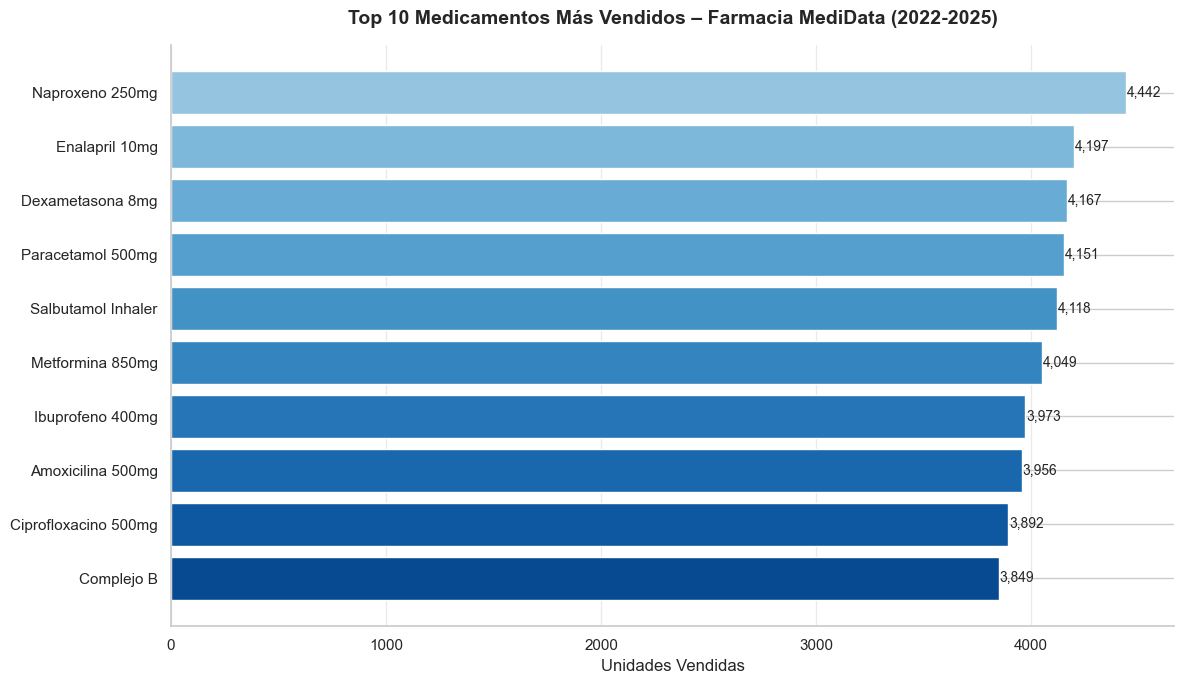

In [55]:
# ─── GRÁFICA 1: Top 10 Medicamentos Más Vendidos ──────────────────────────
fig, ax = plt.subplots(figsize=(12, 7))

colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(df_top_prod)))
bars = ax.barh(df_top_prod['nombre_producto'], df_top_prod['total_unidades'],
               color=colors, edgecolor='white')

# Etiquetas de valor
for bar, val in zip(bars, df_top_prod['total_unidades']):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=10)

ax.set_xlabel('Unidades Vendidas', fontsize=12)
ax.set_title('Top 10 Medicamentos Más Vendidos – Farmacia MediData (2022-2025)',
             fontsize=14, fontweight='bold', pad=15)
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.4)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('grafica_top_productos.png', dpi=150, bbox_inches='tight')
plt.show()


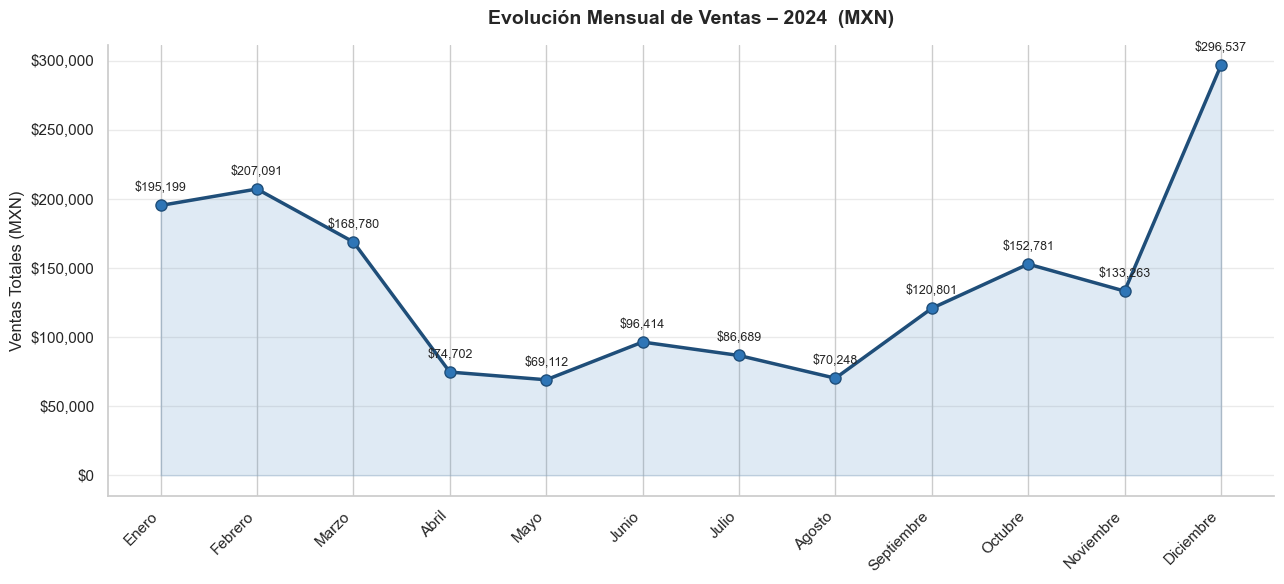

In [56]:
# ─── GRÁFICA 2: Evolución Mensual de Ventas 2024 ──────────────────────────
fig, ax = plt.subplots(figsize=(13, 6))

ax.plot(df_mensual['nombre_mes'], df_mensual['ventas_mes'],
        marker='o', linewidth=2.5, markersize=8,
        color='#1F4E79', markerfacecolor='#2E75B6')
ax.fill_between(range(len(df_mensual)), df_mensual['ventas_mes'],
                alpha=0.15, color='#2E75B6')

# Etiquetas en puntos
for i, (mes, val) in enumerate(zip(df_mensual['nombre_mes'], df_mensual['ventas_mes'])):
    ax.annotate(f'${val:,.0f}', (i, val), textcoords='offset points',
                xytext=(0, 10), ha='center', fontsize=9)

ax.set_xticks(range(len(df_mensual)))
ax.set_xticklabels(df_mensual['nombre_mes'], rotation=45, ha='right')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_title('Evolución Mensual de Ventas – 2024  (MXN)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Ventas Totales (MXN)', fontsize=12)
ax.grid(axis='y', alpha=0.4)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('grafica_ventas_mensuales_2024.png', dpi=150, bbox_inches='tight')
plt.show()


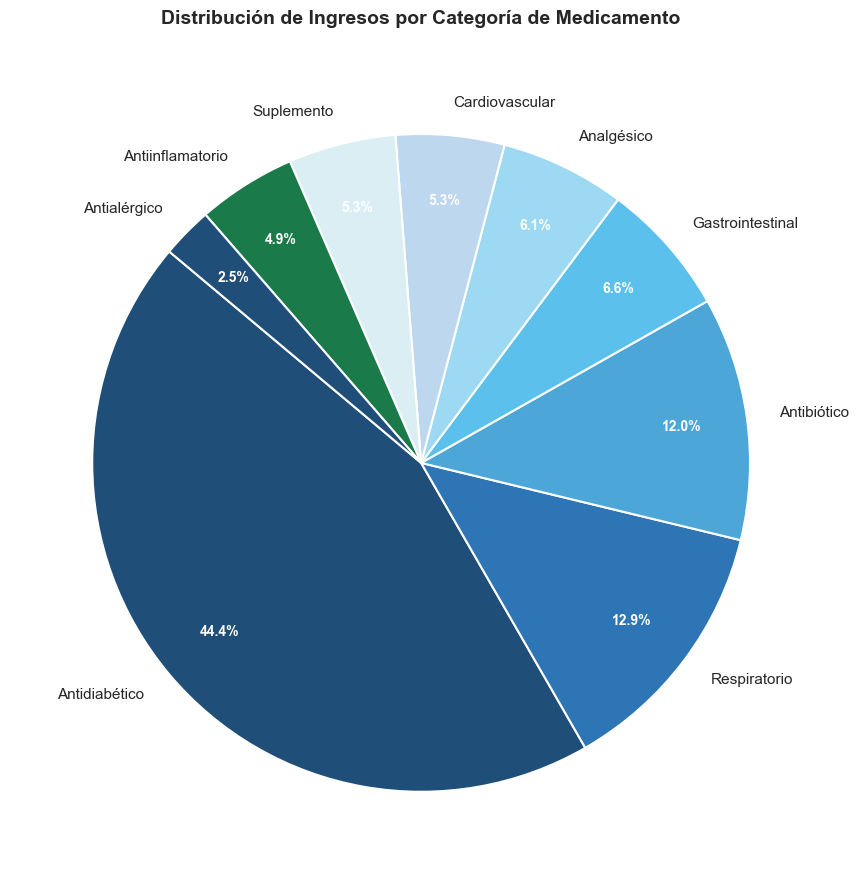

In [57]:
# ─── GRÁFICA 3: Participación de Ventas por Categoría (Pastel) ────────────
fig, ax = plt.subplots(figsize=(9, 9))

colors_pie = ['#1F4E79','#2E75B6','#4DA6D8','#5BC0EB','#9DD9F3',
              '#BDD7EE','#DAEEF3','#1A7A4A']
wedges, texts, autotexts = ax.pie(
    df_cat['ingresos'],
    labels=df_cat['categoria'],
    autopct='%1.1f%%',
    startangle=140,
    colors=colors_pie[:len(df_cat)],
    pctdistance=0.8,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
for at in autotexts:
    at.set_fontsize(10)
    at.set_color('white')
    at.set_fontweight('bold')

ax.set_title('Distribución de Ingresos por Categoría de Medicamento',
             fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('grafica_categoria_pastel.png', dpi=150, bbox_inches='tight')
plt.show()


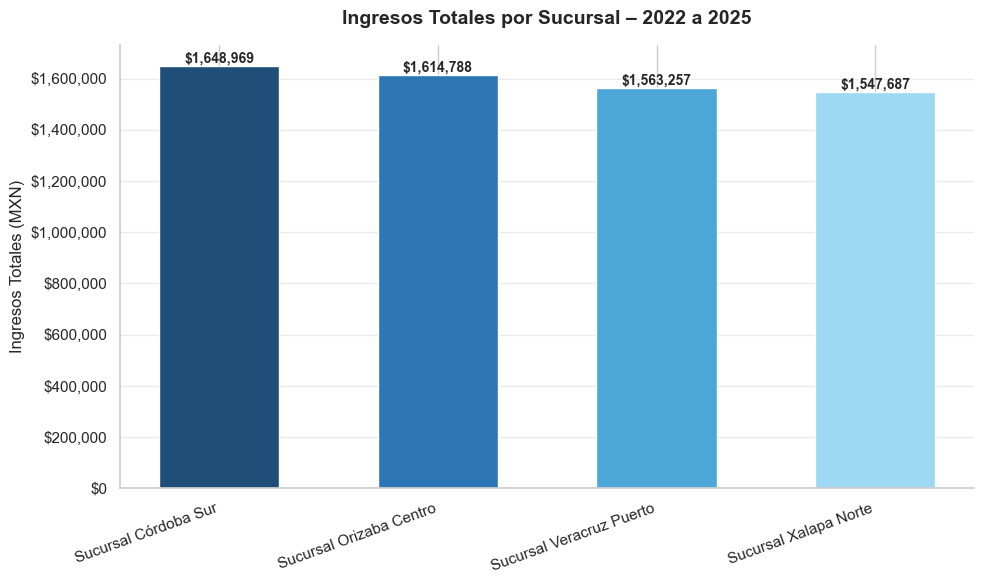

In [58]:
# ─── GRÁFICA 4: Ventas por Sucursal ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

bar_colors = ['#1F4E79', '#2E75B6', '#4DA6D8', '#9DD9F3']
bars = ax.bar(df_sucursal_q['nombre_sucursal'], df_sucursal_q['ingresos_totales'],
              color=bar_colors, edgecolor='white', width=0.55)

for bar, val in zip(bars, df_sucursal_q['ingresos_totales']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2000,
            f'${val:,.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xticklabels(df_sucursal_q['nombre_sucursal'], rotation=20, ha='right')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_title('Ingresos Totales por Sucursal – 2022 a 2025',
             fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Ingresos Totales (MXN)', fontsize=12)
ax.grid(axis='y', alpha=0.4)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('grafica_ventas_sucursal.png', dpi=150, bbox_inches='tight')
plt.show()


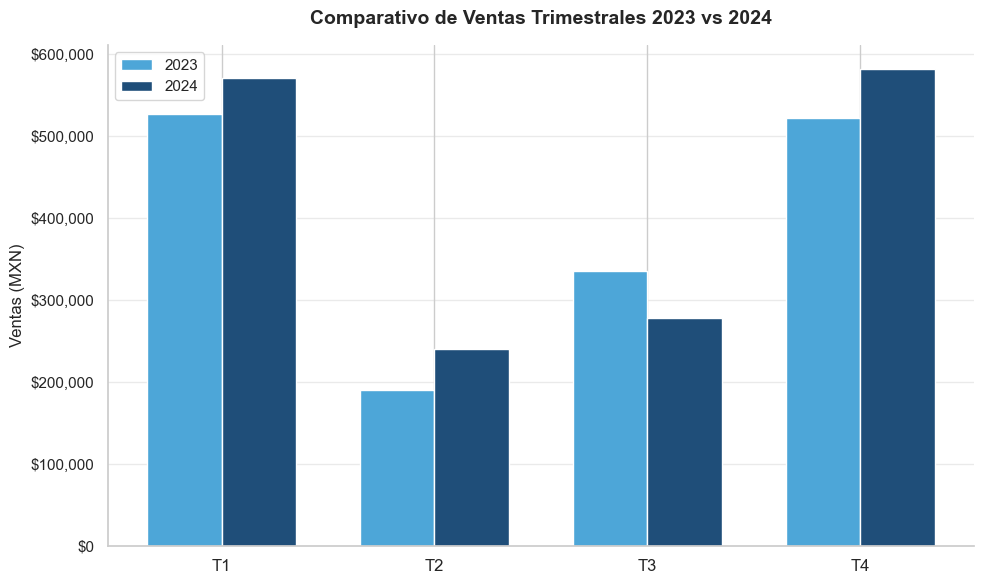

In [59]:
# ─── GRÁFICA 5: Comparativo Trimestral 2023 vs 2024 ───────────────────────
pivot_trim = df_trim.pivot(index='trimestre', columns='anio', values='ventas_trimestre')

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(pivot_trim.index))
w = 0.35

b1 = ax.bar(x - w/2, pivot_trim[2023], width=w, label='2023',
            color='#4DA6D8', edgecolor='white')
b2 = ax.bar(x + w/2, pivot_trim[2024], width=w, label='2024',
            color='#1F4E79', edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels([f'T{q}' for q in pivot_trim.index], fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_title('Comparativo de Ventas Trimestrales 2023 vs 2024',
             fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Ventas (MXN)', fontsize=12)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.4)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('grafica_trimestral_comparativo.png', dpi=150, bbox_inches='tight')
plt.show()


## Resumen Ejecutivo – KPIs Principales

In [60]:
SQL_KPI = """
SELECT
    COUNT(id_venta) AS total_transacciones,
    ROUND(SUM(total_venta)::numeric, 2) AS ingresos_totales,
    ROUND(AVG(total_venta)::numeric, 2) AS ticket_promedio,
    MAX(total_venta) AS venta_maxima,
    SUM(cantidad_vendida) AS unidades_totales
FROM fact_ventas;
"""
df_kpi = pd.read_sql(SQL_KPI, engine)

print('=' * 55)
print('       📊 RESUMEN EJECUTIVO – FARMACIA MEDIDATA')
print('          Período: 2022 – 2025')
print('=' * 55)
print(f'  Transacciones totales : {df_kpi["total_transacciones"][0]:>10,}')
print(f'  Ingresos totales (MXN): ${df_kpi["ingresos_totales"][0]:>13,.2f}')
print(f'  Ticket promedio (MXN) : ${df_kpi["ticket_promedio"][0]:>13,.2f}')
print(f'  Venta máxima (MXN)    : ${df_kpi["venta_maxima"][0]:>13,.2f}')
print(f'  Unidades vendidas     : {df_kpi["unidades_totales"][0]:>10,}')
print('=' * 55)

       📊 RESUMEN EJECUTIVO – FARMACIA MEDIDATA
          Período: 2022 – 2025
  Transacciones totales :     25,000
  Ingresos totales (MXN): $ 6,374,701.46
  Ticket promedio (MXN) : $       254.99
  Venta máxima (MXN)    : $     3,250.00
  Unidades vendidas     :     59,458
